# 03C - xAPI Benchmark Model

This notebook trains and compares machine-learning models for the **xAPI-Edu-Data benchmark dataset** used in the Smart Learning System.

The xAPI model is treated as an **optional research / benchmark model**. It is useful for demonstrating supervised learning on a standard education dataset, but the core Sri Lankan A/L Commerce risk-prediction requirement is handled by the Pass/Fail and Commerce Risk notebooks.

## 1. Notebook Objectives

This notebook will:

- Load the processed xAPI benchmark dataset exported by `02_Data_Preprocessing.ipynb`.
- Validate the encoded feature columns and target variable.
- Prevent target leakage by excluding `Class_Encoded` from the feature matrix.
- Split the dataset into training and testing subsets using stratification.
- Compare Logistic Regression, Decision Tree and Random Forest models.
- Evaluate models using accuracy, balanced accuracy, precision, recall, F1-score, cross-validation and confusion matrices.
- Export comparison reports, feature-importance outputs and summary files for documentation.

In [1]:
from pathlib import Path
import json
import os
import warnings

os.environ.setdefault("MPLCONFIGDIR", "/private/tmp/mplconfig")

import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")
import matplotlib.pyplot as plt
from IPython.display import Image, display as display_image

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)

RANDOM_STATE = 42

## 2. Resolve Project Paths

The notebook is designed to run from either the project root or directly from the notebook folder.

In [2]:
def find_ml_root(start_path=Path.cwd()):
    current = start_path.resolve()
    candidates = [current, *current.parents]
    for candidate in candidates:
        if candidate.name == "ml-model" and (candidate / "datasets").exists():
            return candidate
        nested = candidate / "ml-model"
        if nested.exists() and (nested / "datasets").exists():
            return nested
    raise FileNotFoundError("Could not locate ml-model directory. Run this notebook inside the project repository.")

ML_ROOT = find_ml_root()
PROCESSED_DIR = ML_ROOT / "datasets" / "processed"
REPORTS_DIR = ML_ROOT / "outputs" / "reports"
FIGURES_DIR = ML_ROOT / "outputs" / "figures"
MODELS_DIR = ML_ROOT / "datasets" / "models"

REPORTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
MODELS_DIR.mkdir(parents=True, exist_ok=True)

XAPI_DATASET = PROCESSED_DIR / "xapi_encoded.csv"
METADATA_PATH = PROCESSED_DIR / "preprocessing_metadata.json"

print("ML root:", ML_ROOT)
print("xAPI encoded dataset:", XAPI_DATASET)
print("Reports directory:", REPORTS_DIR)
print("Figures directory:", FIGURES_DIR)

ML root: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model
xAPI encoded dataset: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/datasets/processed/xapi_encoded.csv
Reports directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports
Figures directory: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures


## 3. Load Preprocessing Metadata

The preprocessing notebook exports metadata containing feature names, target mappings and leakage-prevention decisions.

In [3]:
if METADATA_PATH.exists():
    with open(METADATA_PATH, "r") as f:
        metadata = json.load(f)
else:
    metadata = {}

xapi_features_from_metadata = metadata.get("xapi_encoded_feature_names", [])
xapi_target = metadata.get("xapi_target", "Class")
xapi_target_encoding = metadata.get("xapi_target_encoding", {"L": 0, "M": 1, "H": 2})

print("xAPI target:", xapi_target)
print("xAPI target encoding:", xapi_target_encoding)
print("Number of metadata feature columns:", len(xapi_features_from_metadata))
print("Data leakage note:", metadata.get("data_leakage_prevention", "Model transformations are fitted only on training data."))

xAPI target: Class
xAPI target encoding: {'L': 0, 'M': 1, 'H': 2}
Number of metadata feature columns: 72
Data leakage note: Scaling, fitted imputation, encoding objects and resampling are fitted only on the training split during model training.


## 4. Data Leakage Prevention

The processed xAPI file already contains one-hot encoded categorical columns from the preprocessing stage. During model training:

- The target column `Class` is used only as `y`.
- The encoded target helper column `Class_Encoded` is **excluded** from model features.
- Imputation and scaling are fitted inside scikit-learn pipelines using only the training data in each split/fold.
- Cross-validation uses the full pipeline so transformations are refitted separately inside each fold.

## 5. Load xAPI Encoded Dataset

In [4]:
if not XAPI_DATASET.exists():
    raise FileNotFoundError(f"Missing processed xAPI dataset: {XAPI_DATASET}. Run 02_Data_Preprocessing.ipynb first.")

xapi_df = pd.read_csv(XAPI_DATASET)
print("Dataset shape:", xapi_df.shape)
display(xapi_df.head())

Dataset shape: (478, 74)


,raisedhands,VisITedResources,AnnouncementsView,Discussion,gender_F,gender_M,NationalITy_Egypt,NationalITy_Iran,NationalITy_Iraq,NationalITy_Jordan,NationalITy_KW,NationalITy_Lybia,NationalITy_Morocco,NationalITy_Palestine,NationalITy_SaudiArabia,NationalITy_Syria,NationalITy_Tunis,NationalITy_USA,NationalITy_lebanon,NationalITy_venzuela,PlaceofBirth_Egypt,PlaceofBirth_Iran,PlaceofBirth_Iraq,PlaceofBirth_Jordan,PlaceofBirth_KuwaIT,PlaceofBirth_Lybia,PlaceofBirth_Morocco,PlaceofBirth_Palestine,PlaceofBirth_SaudiArabia,PlaceofBirth_Syria,PlaceofBirth_Tunis,PlaceofBirth_USA,PlaceofBirth_lebanon,PlaceofBirth_venzuela,StageID_HighSchool,StageID_MiddleSchool,StageID_lowerlevel,GradeID_G-02,GradeID_G-04,GradeID_G-05,GradeID_G-06,GradeID_G-07,GradeID_G-08,GradeID_G-09,GradeID_G-10,GradeID_G-11,GradeID_G-12,SectionID_A,SectionID_B,SectionID_C,Topic_Arabic,Topic_Biology,Topic_Chemistry,Topic_English,Topic_French,Topic_Geology,Topic_History,Topic_IT,Topic_Math,Topic_Quran,Topic_Science,Topic_Spanish,Semester_F,Semester_S,Relation_Father,Relation_Mum,ParentAnsweringSurvey_No,ParentAnsweringSurvey_Yes,ParentschoolSatisfaction_Bad,ParentschoolSatisfaction_Good,StudentAbsenceDays_Above-7,StudentAbsenceDays_Under-7,Class,Class_Encoded
0,15,16,2,20,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,1,M,1
1,20,20,3,25,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,1,M,1
2,10,7,0,30,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0,L,0
3,30,25,5,35,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0,L,0
4,40,50,12,50,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0,M,1


## 6. Validate Required Columns and Data Types

In [5]:
required_columns = [xapi_target]
missing_required = [column for column in required_columns if column not in xapi_df.columns]
if missing_required:
    raise ValueError(f"Missing required target column(s): {missing_required}")

if xapi_features_from_metadata:
    missing_features = [column for column in xapi_features_from_metadata if column not in xapi_df.columns]
    if missing_features:
        raise ValueError(f"Metadata feature columns missing from xAPI dataset: {missing_features[:10]}")
else:
    xapi_features_from_metadata = [column for column in xapi_df.columns if column not in [xapi_target, "Class_Encoded"]]

print("Required columns are available.")
print("Feature count:", len(xapi_features_from_metadata))
display(pd.DataFrame({"Data Type": xapi_df[xapi_features_from_metadata + [xapi_target]].dtypes.astype(str)}).head(20))

Required columns are available.
Feature count: 72


,Data Type
raisedhands,int64
VisITedResources,int64
AnnouncementsView,int64
Discussion,int64
gender_F,int64
gender_M,int64
NationalITy_Egypt,int64
NationalITy_Iran,int64
NationalITy_Iraq,int64
NationalITy_Jordan,int64


## 7. Leakage Column Check

`Class_Encoded` is an encoded version of the target. It must not be included in `X`.

In [6]:
leakage_columns = ["Class_Encoded"]
available_leakage_columns = [column for column in leakage_columns if column in xapi_df.columns]

xapi_features = [column for column in xapi_features_from_metadata if column not in leakage_columns and column != xapi_target]

print("Class_Encoded present in dataset:", "Class_Encoded" in xapi_df.columns)
print("Leakage-prone columns excluded from X:", available_leakage_columns)
print("Final feature count:", len(xapi_features))

Class_Encoded present in dataset: True
Leakage-prone columns excluded from X: ['Class_Encoded']
Final feature count: 72


## 8. Target Distribution and Class Imbalance

The xAPI benchmark target has three performance classes:

- `L` = Low performance
- `M` = Medium performance
- `H` = High performance

In [7]:
def class_distribution(df, target_col):
    counts = df[target_col].value_counts()
    percentages = df[target_col].value_counts(normalize=True) * 100
    return pd.DataFrame({
        "Count": counts,
        "Percentage": percentages.round(2),
    })

xapi_class_summary = class_distribution(xapi_df, xapi_target)
display(xapi_class_summary)

class_balance_path = REPORTS_DIR / "xapi_class_balance_summary.csv"
xapi_class_summary.to_csv(class_balance_path)
print("Saved:", class_balance_path)

,Count,Percentage
Class,,
M,211,44.14
H,142,29.71
L,125,26.15


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/xapi_class_balance_summary.csv


## 9. Feature and Target Separation

The model input matrix uses only encoded feature columns. The target remains as readable labels (`L`, `M`, `H`) for clearer evaluation reports.

In [8]:
X_xapi = xapi_df[xapi_features].copy()
y_xapi = xapi_df[xapi_target].copy()

print("X shape:", X_xapi.shape)
print("y shape:", y_xapi.shape)
print("Target labels:", sorted(y_xapi.unique().tolist()))
display(X_xapi.head())

X shape: (478, 72)
y shape: (478,)
Target labels: ['H', 'L', 'M']


,raisedhands,VisITedResources,AnnouncementsView,Discussion,gender_F,gender_M,NationalITy_Egypt,NationalITy_Iran,NationalITy_Iraq,NationalITy_Jordan,NationalITy_KW,NationalITy_Lybia,NationalITy_Morocco,NationalITy_Palestine,NationalITy_SaudiArabia,NationalITy_Syria,NationalITy_Tunis,NationalITy_USA,NationalITy_lebanon,NationalITy_venzuela,PlaceofBirth_Egypt,PlaceofBirth_Iran,PlaceofBirth_Iraq,PlaceofBirth_Jordan,PlaceofBirth_KuwaIT,PlaceofBirth_Lybia,PlaceofBirth_Morocco,PlaceofBirth_Palestine,PlaceofBirth_SaudiArabia,PlaceofBirth_Syria,PlaceofBirth_Tunis,PlaceofBirth_USA,PlaceofBirth_lebanon,PlaceofBirth_venzuela,StageID_HighSchool,StageID_MiddleSchool,StageID_lowerlevel,GradeID_G-02,GradeID_G-04,GradeID_G-05,GradeID_G-06,GradeID_G-07,GradeID_G-08,GradeID_G-09,GradeID_G-10,GradeID_G-11,GradeID_G-12,SectionID_A,SectionID_B,SectionID_C,Topic_Arabic,Topic_Biology,Topic_Chemistry,Topic_English,Topic_French,Topic_Geology,Topic_History,Topic_IT,Topic_Math,Topic_Quran,Topic_Science,Topic_Spanish,Semester_F,Semester_S,Relation_Father,Relation_Mum,ParentAnsweringSurvey_No,ParentAnsweringSurvey_Yes,ParentschoolSatisfaction_Bad,ParentschoolSatisfaction_Good,StudentAbsenceDays_Above-7,StudentAbsenceDays_Under-7
0,15,16,2,20,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,1
1,20,20,3,25,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,0,1,0,1,0,1
2,10,7,0,30,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0
3,30,25,5,35,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0
4,40,50,12,50,0,1,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,1,0,0,0,0,1,0,1,0,1,0,1,0,1,0


## 10. Train/Test Split

A stratified split keeps the target-class proportions similar in training and testing datasets.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X_xapi,
    y_xapi,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_xapi,
)

split_summary = pd.DataFrame({
    "Split": ["Training", "Testing"],
    "Rows": [len(y_train), len(y_test)],
})

for label in sorted(y_xapi.unique()):
    split_summary[label] = [
        int((y_train == label).sum()),
        int((y_test == label).sum()),
    ]

display(split_summary)

,Split,Rows,H,L,M
0,Training,382,113,100,169
1,Testing,96,29,25,42


## 11. Define Candidate Models

The same model-family comparison pattern is used across the project notebooks:

- Logistic Regression
- Decision Tree
- Random Forest

Class weighting is used where supported to reduce bias toward the majority class.

In [10]:
models = {
    "Logistic Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(
            max_iter=1000,
            random_state=RANDOM_STATE,
            class_weight="balanced",
        )),
    ]),
    "Decision Tree": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", DecisionTreeClassifier(
            random_state=RANDOM_STATE,
            class_weight="balanced",
            max_depth=8,
        )),
    ]),
    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("model", RandomForestClassifier(
            n_estimators=250,
            random_state=RANDOM_STATE,
            class_weight="balanced",
        )),
    ]),
}

list(models.keys())

['Logistic Regression', 'Decision Tree', 'Random Forest']

## 12. Train Models and Evaluate on Test Set

In [11]:
def evaluate_classifier(model_name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    return {
        "Model": model_name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Balanced Accuracy": balanced_accuracy_score(y_test, y_pred),
        "Macro Precision": precision_score(y_test, y_pred, average="macro", zero_division=0),
        "Macro Recall": recall_score(y_test, y_pred, average="macro", zero_division=0),
        "Macro F1 Score": f1_score(y_test, y_pred, average="macro", zero_division=0),
        "Weighted F1 Score": f1_score(y_test, y_pred, average="weighted", zero_division=0),
    }

trained_models = {}
test_results = []

for model_name, model in models.items():
    metrics = evaluate_classifier(model_name, model, X_train, X_test, y_train, y_test)
    trained_models[model_name] = model
    test_results.append(metrics)

test_results_df = pd.DataFrame(test_results).round(4)
display(test_results_df)

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1 Score,Weighted F1 Score
0,Logistic Regression,0.7708,0.7950,0.7701,0.7950,0.7765,0.7672
1,Decision Tree,0.6562,0.6738,0.6596,0.6738,0.6639,0.6524
2,Random Forest,0.7917,0.7966,0.8013,0.7966,0.7979,0.7911


## 13. Cross-Validation Evaluation

Cross-validation uses the full pipeline so the imputer and scaler are refitted in each fold.

In [12]:
minimum_class_count = int(y_xapi.value_counts().min())
n_splits = min(5, minimum_class_count)
cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=RANDOM_STATE)

scoring = {
    "accuracy": "accuracy",
    "balanced_accuracy": "balanced_accuracy",
    "macro_f1": "f1_macro",
    "weighted_f1": "f1_weighted",
}

cv_rows = []
for model_name, model in models.items():
    scores = cross_validate(model, X_xapi, y_xapi, cv=cv, scoring=scoring, n_jobs=None)
    cv_rows.append({
        "Model": model_name,
        "CV Accuracy": scores["test_accuracy"].mean(),
        "CV Balanced Accuracy": scores["test_balanced_accuracy"].mean(),
        "CV Macro F1 Score": scores["test_macro_f1"].mean(),
        "CV Weighted F1 Score": scores["test_weighted_f1"].mean(),
        "CV Folds": n_splits,
    })

cv_results_df = pd.DataFrame(cv_rows).round(4)
display(cv_results_df)

,Model,CV Accuracy,CV Balanced Accuracy,CV Macro F1 Score,CV Weighted F1 Score,CV Folds
0,Logistic Regression,0.7425,0.7637,0.7522,0.7400,5
1,Decision Tree,0.6946,0.7141,0.7027,0.6910,5
2,Random Forest,0.8158,0.8147,0.8203,0.8156,5


## 14. Combined Model Comparison

In [13]:
comparison_df = test_results_df.merge(cv_results_df, on="Model", how="left")
comparison_df = comparison_df.sort_values(
    by=["Macro F1 Score", "Balanced Accuracy", "CV Macro F1 Score", "CV Balanced Accuracy"],
    ascending=False,
).reset_index(drop=True)

display(comparison_df)

comparison_path = REPORTS_DIR / "xapi_benchmark_model_comparison.csv"
comparison_df.to_csv(comparison_path, index=False)
print("Saved:", comparison_path)

,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1 Score,Weighted F1 Score,CV Accuracy,CV Balanced Accuracy,CV Macro F1 Score,CV Weighted F1 Score,CV Folds
0,Random Forest,0.7917,0.7966,0.8013,0.7966,0.7979,0.7911,0.8158,0.8147,0.8203,0.8156,5
1,Logistic Regression,0.7708,0.7950,0.7701,0.7950,0.7765,0.7672,0.7425,0.7637,0.7522,0.7400,5
2,Decision Tree,0.6562,0.6738,0.6596,0.6738,0.6639,0.6524,0.6946,0.7141,0.7027,0.6910,5


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/xapi_benchmark_model_comparison.csv


## 15. Best Model Selection

For a multi-class benchmark dataset, the best model is selected primarily using **Macro F1 Score** and **Balanced Accuracy**, because these metrics treat all classes more fairly than raw accuracy.

In [14]:
best_model_name = comparison_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

print("Best xAPI Benchmark model:", best_model_name)
print("Selection metrics:")
display(comparison_df.head(1))

Best xAPI Benchmark model: Random Forest
Selection metrics:


,Model,Accuracy,Balanced Accuracy,Macro Precision,Macro Recall,Macro F1 Score,Weighted F1 Score,CV Accuracy,CV Balanced Accuracy,CV Macro F1 Score,CV Weighted F1 Score,CV Folds
0,Random Forest,0.7917,0.7966,0.8013,0.7966,0.7979,0.7911,0.8158,0.8147,0.8203,0.8156,5


## 16. Classification Report for Best Model

In [15]:
y_pred_best = best_model.predict(X_test)
report_dict = classification_report(y_test, y_pred_best, output_dict=True, zero_division=0)
report_text = classification_report(y_test, y_pred_best, zero_division=0)

print(report_text)

report_path = REPORTS_DIR / "xapi_best_model_classification_report.json"
with open(report_path, "w") as f:
    json.dump(report_dict, f, indent=2)

print("Saved:", report_path)

              precision    recall  f1-score   support

           H       0.81      0.72      0.76        29
           L       0.85      0.88      0.86        25
           M       0.75      0.79      0.77        42

    accuracy                           0.79        96
   macro avg       0.80      0.80      0.80        96
weighted avg       0.79      0.79      0.79        96

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/xapi_best_model_classification_report.json


## 17. Confusion Matrix for Best Model

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/xapi_best_model_confusion_matrix.png


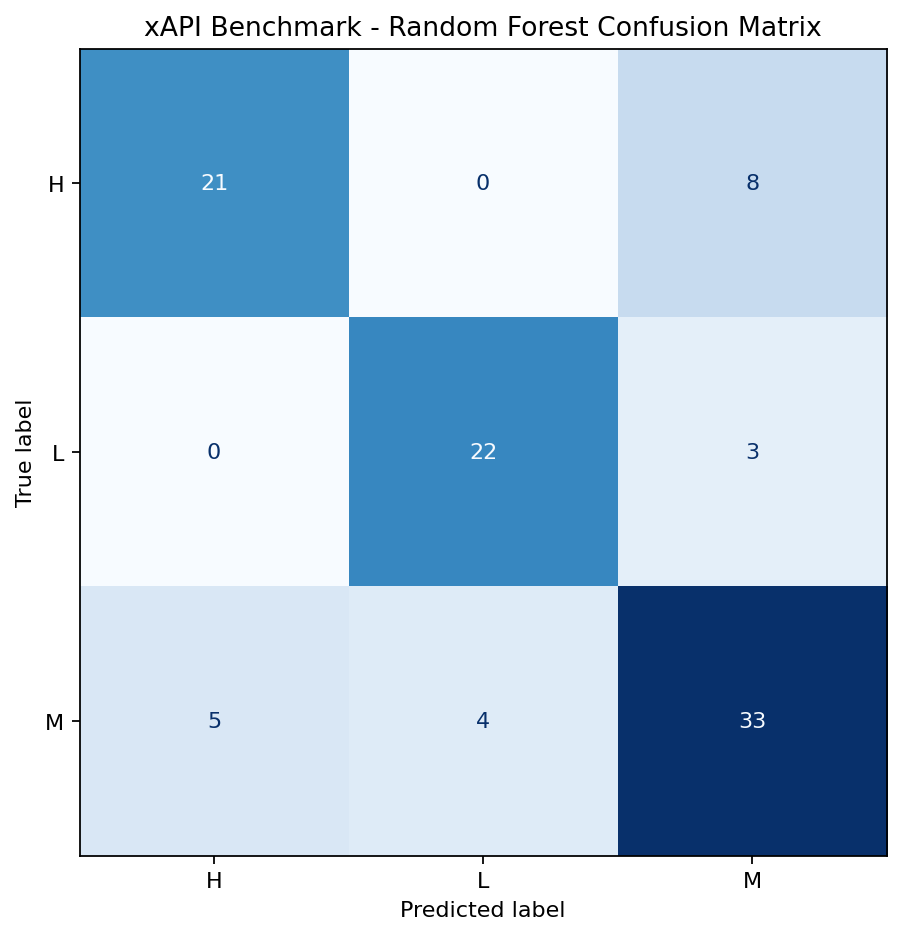

In [16]:
def save_confusion_matrix(model, X_test, y_test, labels, title, output_path):
    predictions = model.predict(X_test)
    matrix = confusion_matrix(y_test, predictions, labels=labels)
    display_obj = ConfusionMatrixDisplay(confusion_matrix=matrix, display_labels=labels)
    fig, ax = plt.subplots(figsize=(7, 6))
    display_obj.plot(ax=ax, cmap="Blues", colorbar=False)
    ax.set_title(title)
    plt.tight_layout()
    fig.savefig(output_path, dpi=160, bbox_inches="tight")
    plt.close(fig)
    print("Saved:", output_path)
    display_image(Image(filename=str(output_path)))

class_labels = sorted(y_xapi.unique().tolist())
best_cm_path = FIGURES_DIR / "xapi_best_model_confusion_matrix.png"
save_confusion_matrix(
    best_model,
    X_test,
    y_test,
    class_labels,
    f"xAPI Benchmark - {best_model_name} Confusion Matrix",
    best_cm_path,
)

## 18. Confusion Matrices for All Models

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/xapi_logistic_regression_confusion_matrix.png


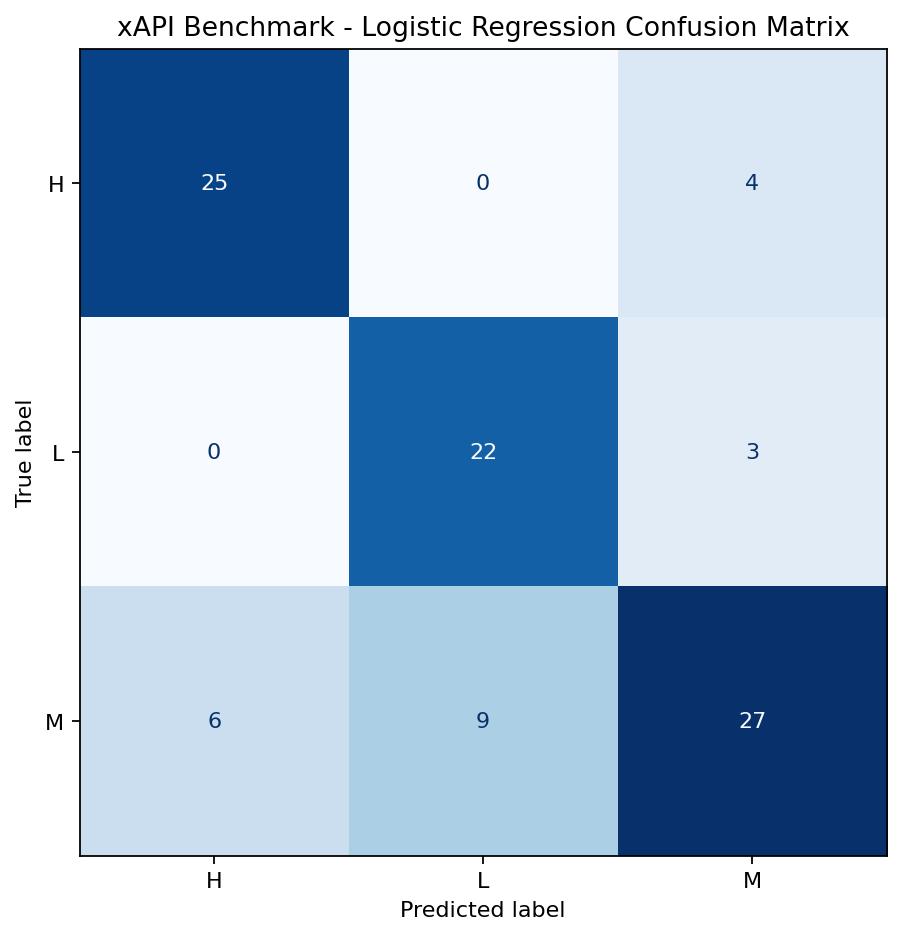

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/xapi_decision_tree_confusion_matrix.png


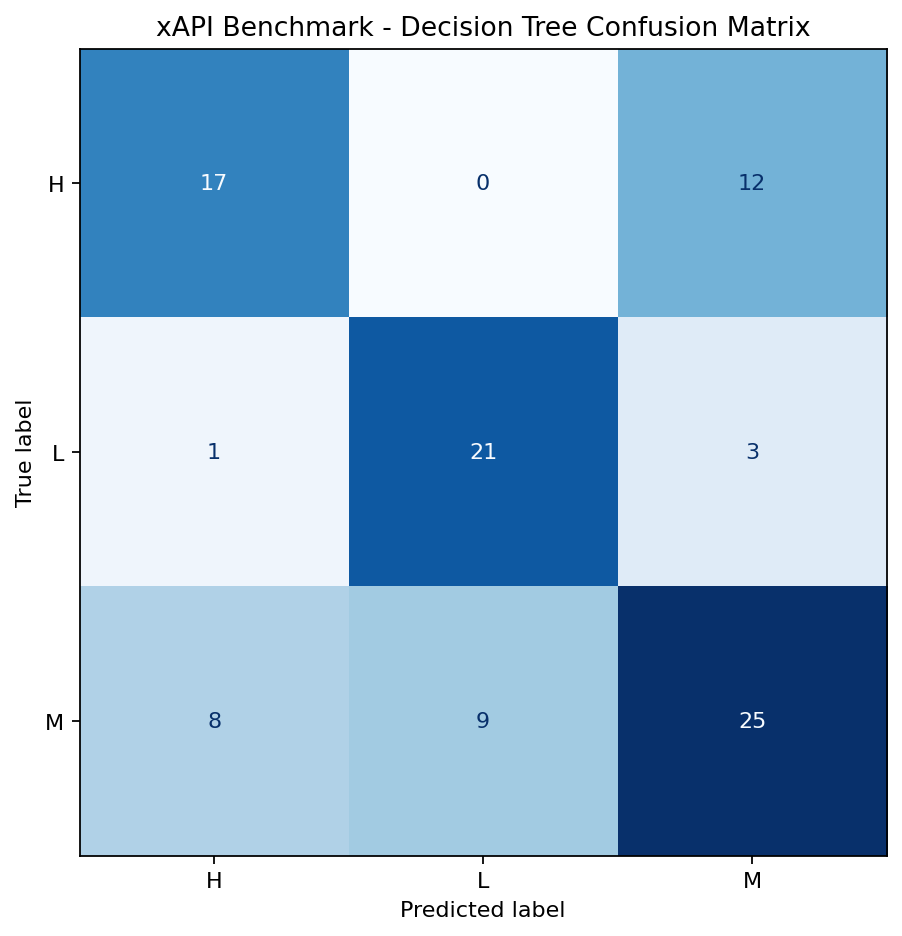

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/figures/xapi_random_forest_confusion_matrix.png


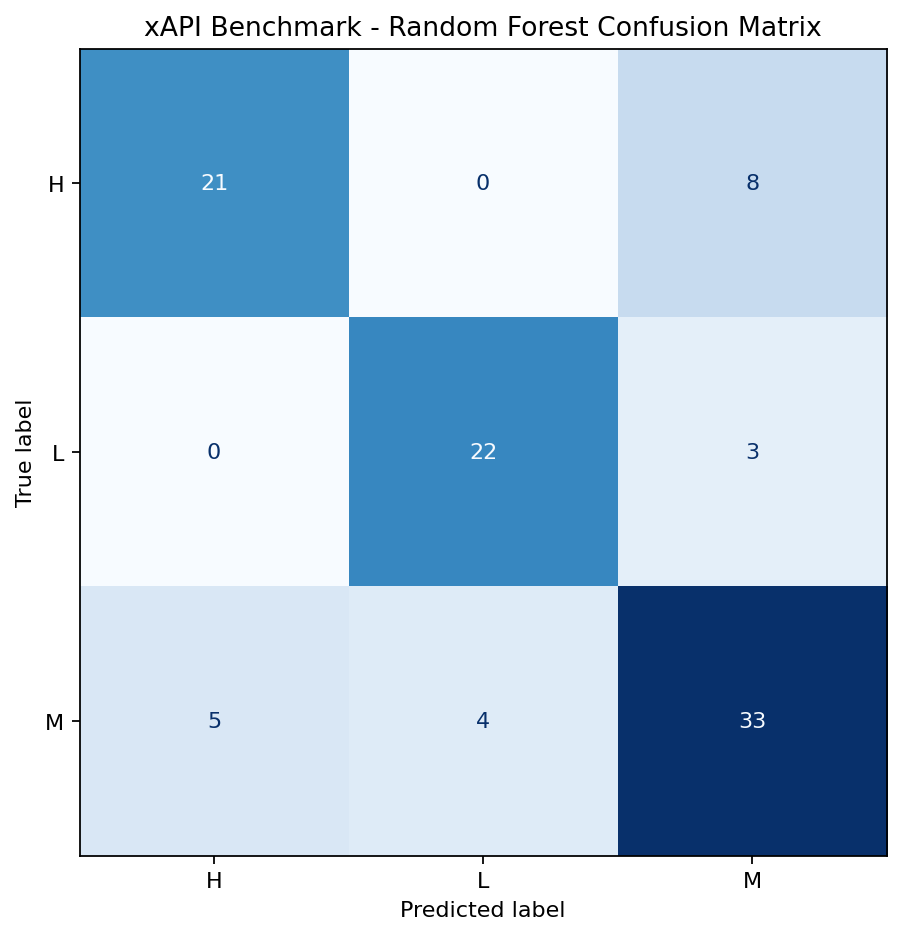

In [17]:
for model_name, model in trained_models.items():
    filename = model_name.lower().replace(" ", "_")
    output_path = FIGURES_DIR / f"xapi_{filename}_confusion_matrix.png"
    save_confusion_matrix(
        model,
        X_test,
        y_test,
        class_labels,
        f"xAPI Benchmark - {model_name} Confusion Matrix",
        output_path,
    )

## 19. Feature Importance / Coefficient Analysis

Tree-based models expose feature importance directly. Logistic Regression coefficients are summarized using mean absolute coefficient magnitude across classes.

In [18]:
importance_rows = []

for model_name, pipeline in trained_models.items():
    model_step = pipeline.named_steps["model"]
    if hasattr(model_step, "feature_importances_"):
        values = model_step.feature_importances_
        for feature, value in zip(xapi_features, values):
            importance_rows.append({
                "Model": model_name,
                "Importance Type": "feature_importance",
                "Feature": feature,
                "Value": value,
            })
    elif hasattr(model_step, "coef_"):
        values = np.mean(np.abs(model_step.coef_), axis=0)
        for feature, value in zip(xapi_features, values):
            importance_rows.append({
                "Model": model_name,
                "Importance Type": "mean_absolute_coefficient",
                "Feature": feature,
                "Value": value,
            })

importance_df = pd.DataFrame(importance_rows)
if not importance_df.empty:
    importance_df = importance_df.sort_values(["Model", "Value"], ascending=[True, False]).reset_index(drop=True)
    display(importance_df.groupby("Model").head(10).round(4))
    importance_path = REPORTS_DIR / "xapi_feature_importance.csv"
    importance_df.to_csv(importance_path, index=False)
    print("Saved:", importance_path)
else:
    print("No feature-importance output available for the trained models.")

,Model,Importance Type,Feature,Value
0,Decision Tree,feature_importance,StudentAbsenceDays_Above-7,0.3116
1,Decision Tree,feature_importance,VisITedResources,0.1849
2,Decision Tree,feature_importance,raisedhands,0.1541
3,Decision Tree,feature_importance,Discussion,0.0839
4,Decision Tree,feature_importance,AnnouncementsView,0.0441
5,Decision Tree,feature_importance,Relation_Mum,0.0341
6,Decision Tree,feature_importance,StageID_MiddleSchool,0.0147
7,Decision Tree,feature_importance,GradeID_G-08,0.0147
8,Decision Tree,feature_importance,NationalITy_Jordan,0.0116
9,Decision Tree,feature_importance,PlaceofBirth_KuwaIT,0.0106


Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/xapi_feature_importance.csv


## 20. Best Model Summary for Documentation

In [19]:
best_summary = {
    "notebook": "03C_xAPI_Benchmark_Model.ipynb",
    "model_purpose": "Optional benchmark model using xAPI-Edu-Data performance classes",
    "dataset": str(XAPI_DATASET),
    "rows": int(xapi_df.shape[0]),
    "feature_count": int(len(xapi_features)),
    "target": xapi_target,
    "target_meaning": {
        "L": "Low performance",
        "M": "Medium performance",
        "H": "High performance",
    },
    "excluded_leakage_columns": available_leakage_columns,
    "candidate_models": list(models.keys()),
    "best_model": best_model_name,
    "selection_basis": "Highest Macro F1 Score, then Balanced Accuracy and cross-validation scores",
    "random_state": RANDOM_STATE,
    "data_leakage_prevention": "Target helper column Class_Encoded is excluded from X. Imputation and scaling are fitted inside train-only pipelines and cross-validation folds.",
    "metrics": comparison_df.to_dict(orient="records"),
}

summary_path = REPORTS_DIR / "xapi_best_model_summary.json"
with open(summary_path, "w") as f:
    json.dump(best_summary, f, indent=2)

print("Saved:", summary_path)

Saved: /Users/admin/Documents/ICBT/Smart-Learning-System/ml-model/outputs/reports/xapi_best_model_summary.json


## 22. Notebook Conclusion

This notebook prepared and evaluated the optional xAPI benchmark model for the Smart Learning System. The encoded xAPI dataset was loaded from the preprocessing outputs, and target leakage was prevented by excluding `Class_Encoded` from the model features.

Three candidate models were compared using test-set metrics and stratified cross-validation: Logistic Regression, Decision Tree and Random Forest. The best benchmark model was selected using Macro F1 Score and Balanced Accuracy, which are more reliable than raw accuracy for multi-class educational-performance prediction.

The generated reports and figures are ready for use in the project documentation and can support the research/demo component of the ML section. However, this xAPI model should be described as an optional benchmark model, while the Pass/Fail and Commerce Risk notebooks remain the core project-aligned risk-prediction models.